<a href="https://colab.research.google.com/github/yash-madake/100-days-of-ml/blob/main/Early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, Activation
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns;

In [ ]:
X,y = make_circles(n_samples = 100 , noise = 0.1 , random_state=1)

<Axes: >

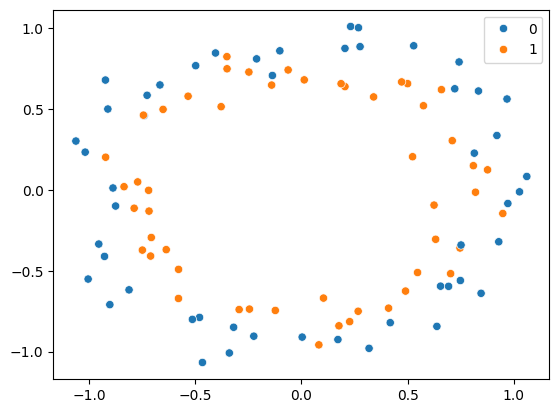

In [ ]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=2)

In [ ]:
model = Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))

model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train,y_train, validation_data= (X_test,y_test),epochs=3500,verbose=0)

KeyboardInterrupt: 

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
plot_decision_regions(X_test,y_test.ravel,clf = model,legend=2)
plt.show()

# Early Stooping

In [ ]:
model = Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from IPython.utils.terminal import restore_term_title
callback = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.0001,
    patience=20,
    verbose=1,
    mode = "auto",
    baseline=None,
    restore_best_weights=False
    )

In [ ]:
history = model.fit(X_train,y_train, validation_data= (X_test,y_test),epochs=3500,callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.4875 - loss: 0.6977 - val_accuracy: 0.6000 - val_loss: 0.6900
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.6953 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5250 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5125 - loss: 0.6913 - val_accuracy: 0.4000 - val_loss: 0.6959
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5250 - loss: 0.6901 - val_accuracy: 0.3500 - val_loss: 0.6989
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5125 - loss: 0.6890 - val_accuracy: 0.3500 - val_loss: 0.7017
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5250 - loss: 0.6883 - val_accuracy: 0.3500 - val_loss: 0.7039
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5375 - loss: 0.6869 - val_accuracy: 0.3500 - 

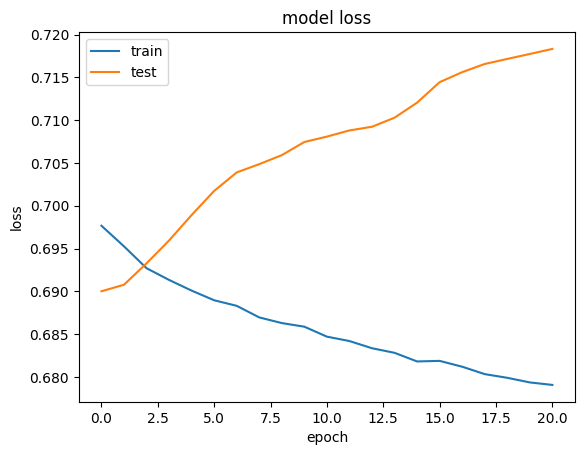

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()